In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Load the dataset
df = pd.read_csv("AmesHousing.csv")
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [14]:
from sklearn.model_selection import train_test_split

x = df.drop(columns=['SalePrice'])
y = df['SalePrice']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42)


print(x_train.head(2), x_test.head(2))
print(y_train.head(2), y_test.head(2))

     Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street  \
381    382  527359050           20        RL          80.0     10400   Pave   
834    835  906475070           60        RL           NaN     28698   Pave   

    Alley Lot Shape Land Contour  ... Screen Porch Pool Area Pool QC  Fence  \
381   NaN       Reg          Lvl  ...            0         0     NaN  MnPrv   
834   NaN       IR2          Low  ...          225         0     NaN    NaN   

    Misc Feature Misc Val Mo Sold Yr Sold  Sale Type  Sale Condition  
381          NaN        0       6    2009        WD           Family  
834          NaN        0       6    2009        WD          Abnorml  

[2 rows x 81 columns]       Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street  \
1357   1358  903427090           70        RM           NaN      5100   Pave   
2367   2368  527450460          160        RM          21.0      1890   Pave   

     Alley Lot Shape Land Contour  ... Screen P

In [18]:
numeric_cols = x_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = x_train.select_dtypes(exclude=[np.number]).columns.tolist()
print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['Order', 'PID', 'MS SubClass', 'Lot Frontage', 'Lot Area', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', 'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'TotRms AbvGrd', 'Fireplaces', 'Garage Yr Blt', 'Garage Cars', 'Garage Area', 'Wood Deck SF', 'Open Porch SF', 'Enclosed Porch', '3Ssn Porch', 'Screen Porch', 'Pool Area', 'Misc Val', 'Mo Sold', 'Yr Sold']
Categorical columns: ['MS Zoning', 'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Heating Q

In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

ordinal_categories = {
    "Lot Shape": ["IR3", "IR2", "IR1", "Reg"],
    "Land Slope": ["Sev", "Mod", "Gtl"],
    "Exter Qual": ["Po", "Fa", "TA", "Gd", "Ex"],
    "Exter Cond": ["Po", "Fa", "TA", "Gd", "Ex"],
    "Bsmt Qual": ["Po", "Fa", "TA", "Gd", "Ex"],
    "Bsmt Cond": ["Po", "Fa", "TA", "Gd", "Ex"],
    "Bsmt Exposure": ["No", "Mn", "Av", "Gd"],
    "BsmtFin Type 1": ["Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
    "BsmtFin Type 2": ["Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
    "Heating QC": ["Po", "Fa", "TA", "Gd", "Ex"],
    "Kitchen Qual": ["Po", "Fa", "TA", "Gd", "Ex"],
    "Functional": ["Sal", "Sev", "Maj2", "Maj1", "Mod", "Min2", "Min1", "Typ"],
    "Fireplace Qu": ["Po", "Fa", "TA", "Gd", "Ex"],
    "Garage Finish": ["Unf", "RFn", "Fin"],
    "Garage Qual": ["Po", "Fa", "TA", "Gd", "Ex"],
    "Garage Cond": ["Po", "Fa", "TA", "Gd", "Ex"],
    "Paved Drive": ["N", "P", "Y"],
    "Pool QC": ["Fa", "TA", "Gd", "Ex"],
    "Fence": ["MnWw", "GdWo", "MnPrv", "GdPrv"],
}

ordinal_cols = [column for column in ordinal_categories if column in categorical_cols]
nominal_cols = [column for column in categorical_cols if column not in ordinal_cols]
ordinal_orders = [ordinal_categories[column] for column in ordinal_cols]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "ordinal",
            OrdinalEncoder(
                categories=ordinal_orders,
                handle_unknown="use_encoded_value",
                unknown_value=-1,
                encoded_missing_value=-2,
            ),
            ordinal_cols,
        ),
        ("nominal", OneHotEncoder(handle_unknown="ignore"), nominal_cols),
        ("numeric", SimpleImputer(strategy="median"), numeric_cols),
    ]
 )

model_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression()),
    ]
 )

model_pipeline.fit(x_train, y_train)
y_pred = model_pipeline.predict(x_test)

print("Ordinal columns:", ordinal_cols)
print("Nominal columns:", nominal_cols)
print("Test MSE:", mean_squared_error(y_test, y_pred))
print("Test R^2:", r2_score(y_test, y_pred))

Ordinal columns: ['Lot Shape', 'Land Slope', 'Exter Qual', 'Exter Cond', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating QC', 'Kitchen Qual', 'Functional', 'Fireplace Qu', 'Garage Finish', 'Garage Qual', 'Garage Cond', 'Paved Drive', 'Pool QC', 'Fence']
Nominal columns: ['MS Zoning', 'Street', 'Alley', 'Land Contour', 'Utilities', 'Lot Config', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Foundation', 'Heating', 'Central Air', 'Electrical', 'Garage Type', 'Misc Feature', 'Sale Type', 'Sale Condition']
Test MSE: 2148078278.3979874
Test R^2: 0.7320779000126565


In [21]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

x_train_prepared = preprocessor.transform(x_train)
x_test_prepared = preprocessor.transform(x_test)

decision_tree = DecisionTreeRegressor(random_state=42)
random_forest = RandomForestRegressor(
    n_estimators=200, random_state=42, n_jobs=-1
 )

models = {
    "Decision Tree": decision_tree,
    "Random Forest": random_forest,
}

for name, model in models.items():
    model.fit(x_train_prepared, y_train)
    predictions = model.predict(x_test_prepared)
    print(name)
    print("  Test MSE:", mean_squared_error(y_test, predictions))
    print("  Test R^2:", r2_score(y_test, predictions))

Decision Tree
  Test MSE: 1193010715.006826
  Test R^2: 0.8512000520249149
Random Forest
  Test MSE: 714414263.7902141
  Test R^2: 0.9108936709893386


In [ ]:
comparison_predictions = {
    "Linear Regression": model_pipeline.predict(x_test),
    "Decision Tree": decision_tree.predict(x_test_prepared),
    "Random Forest": random_forest.predict(x_test_prepared),
}

comparison_table = pd.DataFrame(
    [
        {
            "Model": name,
            "MSE": mean_squared_error(y_test, predictions),
            "RMSE": np.sqrt(mean_squared_error(y_test, predictions)),
            "R²": r2_score(y_test, predictions),
        }
        for name, predictions in comparison_predictions.items()
    ]
).sort_values("RMSE").reset_index(drop=True)

comparison_table.style.format(
    {"MSE": "{:,.0f}", "RMSE": "{:,.0f}", "R²": "{:.3f}"}
 )

Top 10 numeric features by absolute correlation:
Overall Qual      0.799262
Gr Liv Area       0.706780
Garage Cars       0.647877
Garage Area       0.640401
Total Bsmt SF     0.632280
1st Flr SF        0.621676
Year Built        0.558426
Full Bath         0.545604
Year Remod/Add    0.532974
Garage Yr Blt     0.526965
Name: SalePrice, dtype: float64


Top 10 numeric features by absolute correlation:
Overall Qual      0.799262
Gr Liv Area       0.706780
Garage Cars       0.647877
Garage Area       0.640401
Total Bsmt SF     0.632280
1st Flr SF        0.621676
Year Built        0.558426
Full Bath         0.545604
Year Remod/Add    0.532974
Garage Yr Blt     0.526965
Name: SalePrice, dtype: float64


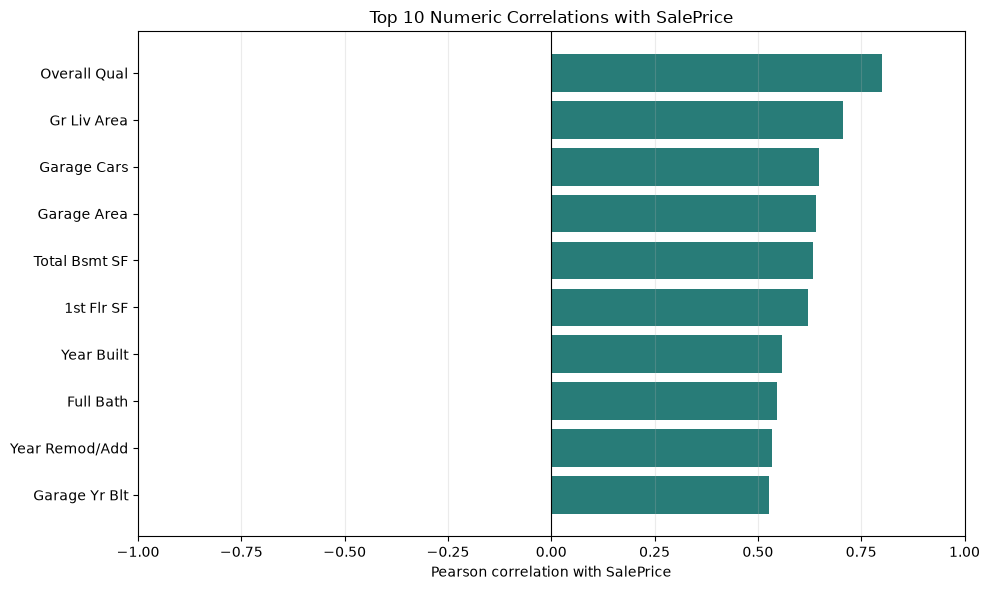

Top 10 numeric features by absolute correlation:
Overall Qual      0.799262
Gr Liv Area       0.706780
Garage Cars       0.647877
Garage Area       0.640401
Total Bsmt SF     0.632280
1st Flr SF        0.621676
Year Built        0.558426
Full Bath         0.545604
Year Remod/Add    0.532974
Garage Yr Blt     0.526965
Name: SalePrice, dtype: float64


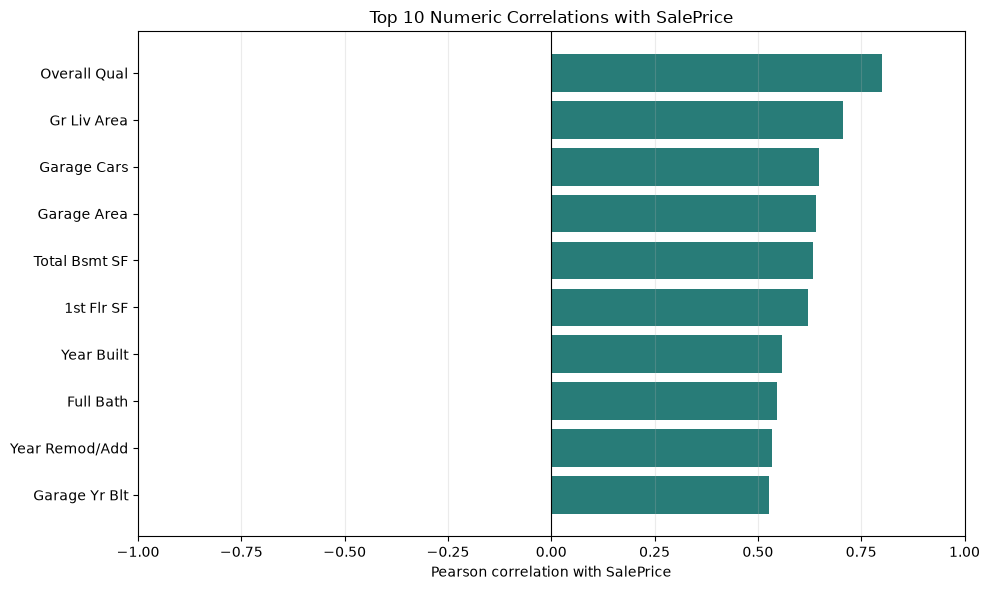

Features shown in scatterplots: ['Overall Qual', 'Gr Liv Area', 'Garage Cars', 'Garage Area', 'Total Bsmt SF', '1st Flr SF']


Top 10 numeric features by absolute correlation:
Overall Qual      0.799262
Gr Liv Area       0.706780
Garage Cars       0.647877
Garage Area       0.640401
Total Bsmt SF     0.632280
1st Flr SF        0.621676
Year Built        0.558426
Full Bath         0.545604
Year Remod/Add    0.532974
Garage Yr Blt     0.526965
Name: SalePrice, dtype: float64


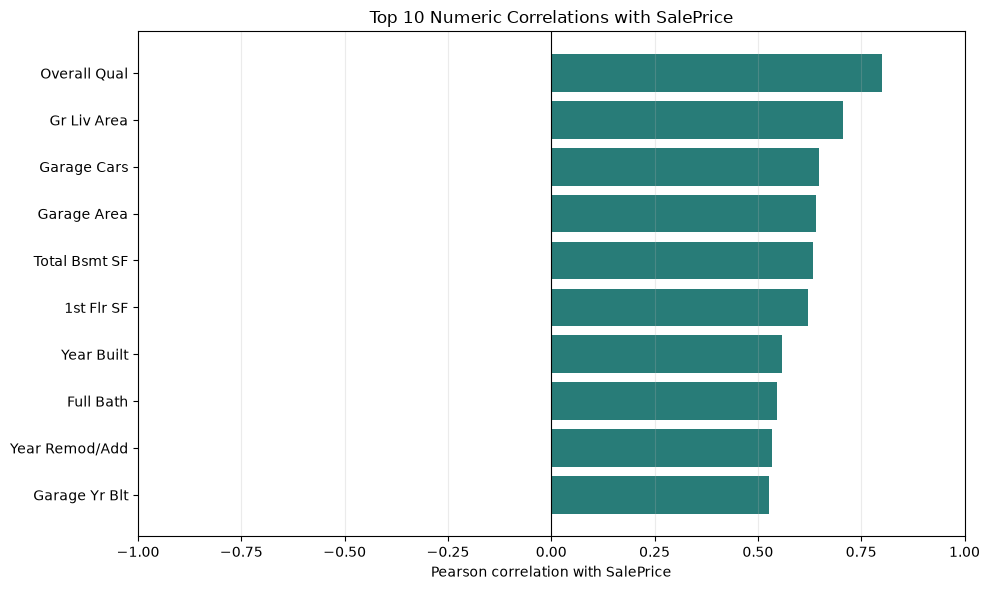

Features shown in scatterplots: ['Overall Qual', 'Gr Liv Area', 'Garage Cars', 'Garage Area', 'Total Bsmt SF', '1st Flr SF']


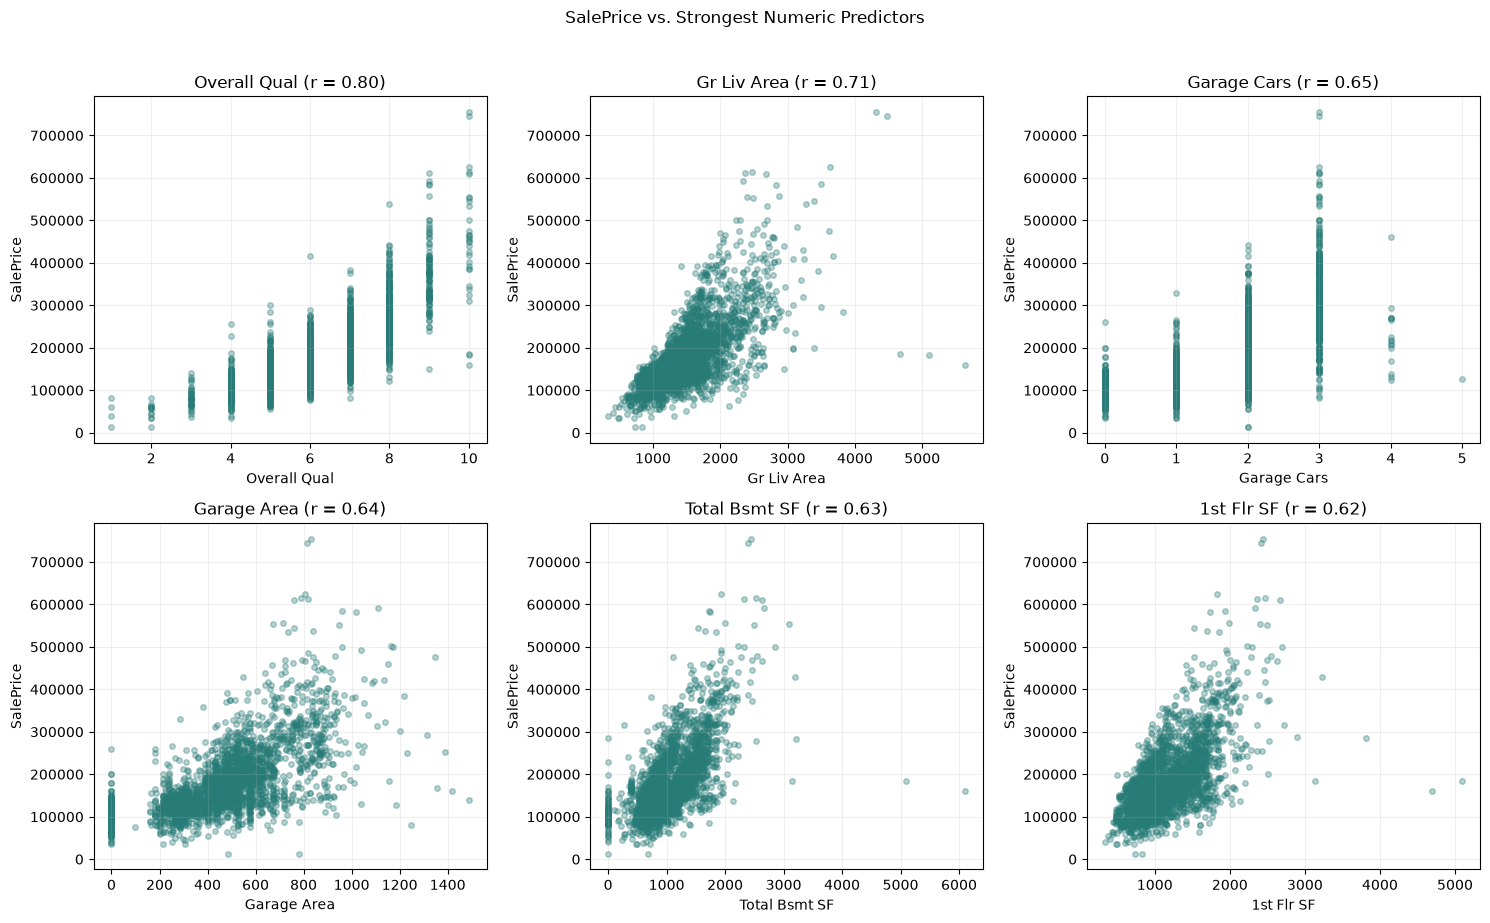

In [23]:
numeric_data = df.select_dtypes(include=[np.number]).drop(
    columns=["Order", "PID"], errors="ignore"
 )

price_correlations = numeric_data.corr()["SalePrice"].drop("SalePrice").dropna()
top_correlations = price_correlations.reindex(
    price_correlations.abs().sort_values(ascending=False).head(10).index
 ).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = ["#b84a4a" if value < 0 else "#287c78" for value in top_correlations]
ax.barh(top_correlations.index, top_correlations.values, color=bar_colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlim(-1, 1)
ax.set_xlabel("Pearson correlation with SalePrice")
ax.set_title("Top 10 Numeric Correlations with SalePrice")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

top_features = price_correlations.abs().sort_values(ascending=False).head(6).index
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, feature in zip(axes.flat, top_features):
    ax.scatter(df[feature], df["SalePrice"], alpha=0.35, s=16, color="#287c78")
    ax.set_title(f"{feature} (r = {price_correlations[feature]:.2f})")
    ax.set_xlabel(feature)
    ax.set_ylabel("SalePrice")
    ax.grid(alpha=0.2)

for ax in axes.flat[len(top_features):]:
    ax.set_visible(False)

fig.suptitle("SalePrice vs. Strongest Numeric Predictors", y=1.02)
fig.tight_layout()
plt.show()

In [24]:
# Identify the features used in the correlation graphs
numeric_data = df.select_dtypes(include=[np.number]).drop(
    columns=["Order", "PID"], errors="ignore"
 )
feature_correlations = numeric_data.corr()["SalePrice"].drop("SalePrice").dropna()

top_10_features = feature_correlations.abs().sort_values(ascending=False).head(10)
scatterplot_features = feature_correlations.abs().sort_values(ascending=False).head(6)

print("Top 10 features in the correlation chart:")
print(feature_correlations.loc[top_10_features.index].sort_values(key=abs, ascending=False))

print("\nFeatures in the scatterplots:")
print(feature_correlations.loc[scatterplot_features.index].sort_values(key=abs, ascending=False))

Top 10 features in the correlation chart:
Overall Qual      0.799262
Gr Liv Area       0.706780
Garage Cars       0.647877
Garage Area       0.640401
Total Bsmt SF     0.632280
1st Flr SF        0.621676
Year Built        0.558426
Full Bath         0.545604
Year Remod/Add    0.532974
Garage Yr Blt     0.526965
Name: SalePrice, dtype: float64

Features in the scatterplots:
Overall Qual     0.799262
Gr Liv Area      0.706780
Garage Cars      0.647877
Garage Area      0.640401
Total Bsmt SF    0.632280
1st Flr SF       0.621676
Name: SalePrice, dtype: float64
